# Calculate product footprints and generate hotspot figure

## Notebook README

This work is licenced under the Creative Commons Attribution (CC-BY 4.0) public licence.

**Related publication**

If you utilize any portions of the code, results, or draw inspiration for your projects, please reference the published article below.

 - Title: Residual biomass to bio-based chemicals and plastics: ex-ante screening methodology for prioritizing high-impact substitutions
 - Authors: [Nicolas LIENART](https://orcid.org/0009-0001-3259-2819), [Thibaut LECOMPTE](https://orcid.org/0000-0001-9237-8454), [Lorie HAMELIN](https://orcid.org/0000-0001-9092-1900) 
 - Journal: Resources, Conservation and Recycling (RCR) - Elsevier
 - Doi: #todo
 - Code author: Nicolas LIENART
 - Git repository (Forge INRAE): https://forge.inrae.fr/nicolas.lienart/screen-lca-paper-supplementary-code
 - Git repository (GitHub): https://github.com/nicolnt/screen-lca-paper-supplementary-code

**Description and details**

This code generates the hotspot figure (Figure 2) showing the import and production amount of chemicals and plastics in the EU27, their unit GHG footprint (cradle-to-gate), the total estimated footprint (cradle-to-gate) and the estimated end of life impacts. Refer to the aforementioned main manuscript and accompanying supplementary information documents for more details.

**Updates**

 - May 04, 2026: Ready for submission
 - August 11, 2026: Refactor code. Add support for multiple Ecoinvent database version. Split activities in multiple regions. Removed check in the function for substances LCA that could prevent further recursive calls despite behing possibly relevants.

**Package versions**

 - See [`environment.yml`](./environment.yml)

**Relevant references**

ChatGPT was used to help with the SVG post-treatment.

- Prompts:
  - `Using matplotlib, I want to export the figure as a svg. But instead of each bars of each plt.bar having a name as "patch_xx" and containing "pathxx", where xx are digits, I want it to have meaningful names, based on dataframe data and index. How shoul I proceed?`
  - `How can I put all bars in "ax.bar" in a same parent svg group, also named.`
  - `This does not work, I get the following error: AttributeError: 'BarContainer' object has no attribute 'set_gid'`
  - `How can I make pyplot to stop putting single paths in groups when exporting to svg?`
  - `Using XPath syntax, how do I select all groups that are in the group with id="hello"`
- Public link: https://chatgpt.com/share/693bf85f-d4bc-8009-9538-189cdfdd7e83

## Initialization

### Python imports

In [95]:
import bw2data as bd
import bw2io as bi
import bw2calc as bc
import pandas as pd
import numpy as np
import re

In [2]:
from importlib.metadata import version
print('bw2data:', version('bw2data'))
print('bw2io:', version('bw2io'))
print('bw2calc:', version('bw2calc'))
print('pandas:', version('pandas'))
print('numpy:', version('numpy'))
print('matplotlib:', version('matplotlib'))

bw2data: 4.6.2
bw2io: 0.9.17
bw2calc: 2.4.0
pandas: 2.2.3
numpy: 2.4.3
matplotlib: 3.10.9


### Import some global variables from file

Your `.env` file is a collection of key-value pairs, separated by a `=` sign. It should contain these lines with the relevant values:

```bash
ecoinvent_username="replace_with your Ecoinvent's licence username"
ecoinvent_password="replace_with your Ecoinvent's licence password"
project_name="replace with project name"
```

We can then access this information with the dotenv and Python's built-in `os` libraries.

In [3]:
import os
from dotenv import load_dotenv  # To read the contents of the .env file

load_dotenv(override=True)

# NOTE: Get Ecoinvent account login details from a different file
ECOINVENT_USERNAME = os.getenv("ecoinvent_username")
ECOINVENT_PASSWORD = os.getenv("ecoinvent_password")

PROJECT_NAME = os.getenv("project_name")

In [ ]:
# NOTE: Manually set Brightway current project
# PROJECT_NAME = "a-brightway-project"

## Setup Brightway project

In [ ]:
# NOTE: List Brightway projects
sorted(bd.projects)

In [5]:
# NOTE: Select the brightway project to use for this notebook
bd.projects.set_current(name=PROJECT_NAME)
bd.projects.current

'20260809-paper-1-screen-lca'

### Import Ecoinvent (required only once per project and Ecoinvent database version)

In [ ]:
# NOTE: Download and load ecoinvent into the current project. Takes several minutes to complete.
bi.import_ecoinvent_release(
    version='3.12',
    system_model='cutoff',
    username=ECOINVENT_USERNAME, 
    password=ECOINVENT_PASSWORD 
)

In [6]:
# NOTE: List available databases in the current Brightway project
bd.databases

Databases dictionary with 4 object(s):
	ecoinvent-3.11-biosphere
	ecoinvent-3.11-cutoff
	ecoinvent-3.12-biosphere
	ecoinvent-3.12-cutoff

## Additional global variables

In [7]:
ECOINVENT_DATABASE_NAMES = ['ecoinvent-3.11-cutoff', 'ecoinvent-3.12-cutoff']

In [8]:
SUBSTANCE_LIST = [
    {
        "name":'propylene',
        "CAS":'115-07-1'
    },
    {
        "name":'ethylene',
        "CAS":'74-85-1'
    },
    {
        "name":'methanol',
        "CAS":'000067-56-1'
    },
    {
        "name":'xylene, mixed',
        "CAS":'',
        "type": "BTX"
    },
    {
        "name":'o-xylene',
        "CAS":'000095-47-6',
        "type": "BTX"
    },
    {
        "name":'p-xylene',
        "CAS":'000106-42-3',
        "type": "BTX"
    },
    {
        "name":'toluene, liquid',
        "CAS":'108-88-3',
        "type": "BTX"
    },
    {
        "name":'benzene',
        "CAS":'000071-43-2',
        "type": "BTX"
    }
]

In [9]:
# NOTE: Select the right method
# Optional additional condition to take the method from a specific Ecoinvent database version: `m[0] == "ecoinvent-3.12"`
GWP_KEYS = [m for m in bd.methods if "climate change: total (excl. biogenic CO2)" == m[2] and "IPCC 2021" == m[1] and "global warming potential (GWP100)" == m[3]]
GWP_KEYS

[('ecoinvent-3.11',
  'IPCC 2021',
  'climate change: total (excl. biogenic CO2)',
  'global warming potential (GWP100)'),
 ('ecoinvent-3.12',
  'IPCC 2021',
  'climate change: total (excl. biogenic CO2)',
  'global warming potential (GWP100)')]

In [10]:
ECOINVENT_DATABASES = {}

# NOTE: Prepare LCA object
for ecoinvent_database_name in ECOINVENT_DATABASE_NAMES:
    ecoinvent_database_dict = {}

    # NOTE: Produces a string which looks something like "ecoinvent-x.x.x" out of "ecoinvent-x.x.x-model"
    method_key_db_name = "-".join(ecoinvent_database_name.split("-")[0:2])

    # NOTE: Select the relevant key, based on Ecoinvent version (no matter the system model)
    gwp_key = [key for key in GWP_KEYS if method_key_db_name in key[0]][0]
    ecoinvent_database_dict['gwp_key'] = gwp_key

    db = bd.Database(ecoinvent_database_name)
    ecoinvent_database_dict['db'] = db

    # NOTE: The selected activity here do not matter much. AN activity is required to run an LCA (`demand` parameter)
    random_activity = db.random()

    # NOTE: Create the LCA object and run the calculation
    lca = bc.LCA(demand={random_activity.id: 1}, method=gwp_key)
    lca.lci()

    ecoinvent_database_dict['lca'] = lca

    ECOINVENT_DATABASES[ecoinvent_database_name] = ecoinvent_database_dict

ECOINVENT_DATABASES

{'ecoinvent-3.11-cutoff': {'gwp_key': ('ecoinvent-3.11',
   'IPCC 2021',
   'climate change: total (excl. biogenic CO2)',
   'global warming potential (GWP100)'),
  'db': Brightway2 SQLiteBackend: ecoinvent-3.11-cutoff,
  'lca': <bw2calc.lca.LCA at 0x7f2adc1ddd30>},
 'ecoinvent-3.12-cutoff': {'gwp_key': ('ecoinvent-3.12',
   'IPCC 2021',
   'climate change: total (excl. biogenic CO2)',
   'global warming potential (GWP100)'),
  'db': Brightway2 SQLiteBackend: ecoinvent-3.12-cutoff,
  'lca': <bw2calc.lca.LCA at 0x7f2adc1b3c50>}}

## Import Prodcom CSV data

In [227]:
pd.options.display.max_columns = 100

In [ ]:
# NOTE: CSV file format must be as below

input_table = pd.read_csv('output/20260811 - prodcom_data with ecoinvent activities.csv', index_col=0, dtype={
    'PRODCOM code': str,
    'HS22 code': str,
})

# NOTE: Remove unused columns from the CSV
input_table = input_table.loc[:, ~input_table.columns.isin(["Carbon atoms", "Molecular weight (MW)", "Molecular formula (MF)", "HS22 code", "Note and references", "MF and MW reference"])].copy()

In [228]:
input_table

,PRODCOM code,Long name,Figure name,Quantity (kg/yr),Quantity (Mt/yr),Local production share of available quantity (%),Ecoinvent 3.11 activity name proxy,Carbon mass share,Ecoinvent 3.11 activity region 1 location,Ecoinvent 3.11 activity region 1 share,Ecoinvent 3.11 activity region 2 location,Ecoinvent 3.11 activity region 2 share,Ecoinvent 3.11 activity region 3 location,Ecoinvent 3.11 activity region 3 share,Ecoinvent 3.12 activity region 1 location,Ecoinvent 3.12 activity region 1 share,Ecoinvent 3.12 activity region 2 location,Ecoinvent 3.12 activity region 2 share,Ecoinvent 3.12 activity region 3 location,Ecoinvent 3.12 activity region 3 share,Ecoinvent 3.12 activity region 4 location,Ecoinvent 3.12 activity region 4 share,Ecoinvent 3.12 activity region 5 location,Ecoinvent 3.12 activity region 5 share
id,,,,,,,,,,,,,,,,,,,,,,,,
0,20165130,"Polypropylene, in primary forms",Polypropylene,1.105982e+10,11.059816,0.864021,"market for polypropylene, granulate",0.856277,GLO,1.00,NaN,NaN,NaN,NaN,RER,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20141130,Ethylene,Ethylene,1.033749e+10,10.337494,0.879049,market for ethylene,0.856399,RER,1.00,NaN,NaN,NaN,NaN,RER w/o RU,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20141140,Propene (propylene),Propylene,9.081741e+09,9.081741,0.944094,market for propylene,0.856298,RER,1.00,NaN,NaN,NaN,NaN,RER w/o RU,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20161050,Polyethylene having a specific gravity of >= 0...,Polyethylene,7.628879e+09,7.628879,0.783693,"market for polyethylene, high density, granulate",0.856277,GLO,1.00,NaN,NaN,NaN,NaN,RER,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20142210,Methanol (methyl alcohol),Methanol,6.904732e+09,6.904732,0.141932,market for methanol,0.374852,RER,0.35,US,0.23,RoW,0.42,US,0.23,TT,0.21,RER w/o RU,0.18,RU,0.16,RoW,0.22
5,20141223,Benzene,Benzene,6.234476e+09,6.234476,0.882871,market for benzene,0.922622,RER,1.00,NaN,NaN,NaN,NaN,RER,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,20163010,"Polyvinyl chloride, not mixed with any other s...",Polyvinyl chloride,5.008047e+09,5.008047,0.892722,"market for polyvinyl chloride, emulsion polyme...",0.384352,RER,1.00,NaN,NaN,NaN,NaN,RER,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,20161039,"Polyethylene having a specific gravity < 0,94,...",Polyethylene,4.474214e+09,4.474214,0.796107,"market for polyethylene, low density, granulate",0.856277,GLO,1.00,NaN,NaN,NaN,NaN,RER,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,20161035,Linear polyethylene having a specific gravity ...,Polyethylene,4.238710e+09,4.238710,0.822538,"market for polyethylene, linear low density, g...",0.856277,GLO,1.00,NaN,NaN,NaN,NaN,GLO,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## General functions

In [145]:
def ecoinvent_region_and_share_series_to_df(ecoinvent_region_data):

    # NOTE: Extract the part of the name that is common to use as index
    ecoinvent_region_index = [re.split(r"(^.*region \d)", s)[1] for s in ecoinvent_region_data.loc[ecoinvent_region_data.index.str.endswith('location')].index.values]            

    # NOTE: Construct the dataframe
    return pd.DataFrame([
            ecoinvent_region_data.loc[ecoinvent_region_data.index.str.endswith('location')].values,
            ecoinvent_region_data.loc[ecoinvent_region_data.index.str.endswith('share')].values
        ], index=['location', 'share'], columns=ecoinvent_region_index).T

In [205]:
# NOTE: calculate LCA score for a product by reusing a pre-calculated Brightway LCA object
def calculate_LCA(code, ecoinvent_version: str = 'ecoinvent-3.11-cutoff', amount=1):
    ecoinvent_database_dict = ECOINVENT_DATABASES[ecoinvent_version]

    activity = ecoinvent_database_dict["db"].get(code)
    
    # NOTE: Reuse the LCA object created before.
    # Source: https://github.com/brightway-lca/brightway2/blob/master/notebooks/Using%20redo_lci%20and%20redo_lcia.ipynb
    # No big improvement noticed.
    ecoinvent_database_dict["lca"].lcia(demand={activity.id: amount})
    return ecoinvent_database_dict["lca"].score

In [222]:
def lca_contribution_of_substance(activity_code, substance, recursive_call_left, ecoinvent_version: str = 'ecoinvent-3.11-cutoff', cutoff=1):

    activity = ECOINVENT_DATABASES[ecoinvent_version]["db"].get(activity_code)
    
    # NOTE: Reached the end of the recursive path, don't go further.
    if recursive_call_left == 0:
        return 0
    
    else:
        # NOTE: For each technosphere exchanges except itself
        exchanges = [m for m in activity.exchanges() if m['type'] == 'technosphere']
        
        if len(exchanges) > 0:
            activity_score = 0
            for exchange in exchanges:

                exchange_code = exchange['input'][1]
                exchange_amount = exchange['amount']
                
                # NOTE: Optimisation: Check if activity ISIC code is != than '19', '20', '21', '22'
                isic_code = ''
                if 'classifications' in exchange.input.as_dict() \
                    and len([e for e in exchange.input.as_dict()['classifications'] if e[0] == 'ISIC rev.4 ecoinvent']) > 0:
                    isic_code = [e for e in exchange.input.as_dict()['classifications'] if e[0] == 'ISIC rev.4 ecoinvent'][0][1]
                    if isic_code == '' or isic_code[0:2] not in ['19', '20', '21', '22']:
                        continue

                # NOTE: Optimisation: Apply a cutoff on the mass
                new_cutoff = cutoff
                if exchange['unit'] == activity['unit'] and activity['unit'] == 'kilogram':
                    share = exchange['amount'] / activity['production amount']
                    if share < cutoff:
                        continue
                    else:
                        new_cutoff = cutoff * (1/share)

                # NOTE: If CAS or name is matched, calculate and return footprint and stop there.
                if ('CAS number' in exchange and exchange['CAS number'] == substance['CAS']) or exchange['name'].lower() == substance['name'].lower():
                    activity_score += calculate_LCA(code=exchange_code, ecoinvent_version=ecoinvent_version, amount=exchange_amount)
                else:
                    exchange_score = exchange_amount * lca_contribution_of_substance(
                        activity_code=exchange_code,
                        substance=substance,
                        recursive_call_left=(recursive_call_left-1),
                        cutoff=new_cutoff,
                        ecoinvent_version=ecoinvent_version
                        )
                    
                    activity_score += exchange_score

            return activity_score
        
        # NOTE: No exchanges. Stop current recursive path
        else:
            return 0

In [160]:
def get_activity_by_name_location_priority(name, location_priority = ['RER', 'GLO', 'RoW'], ecoinvent_version: str = 'ecoinvent-3.12-cutoff'):
    activities = [a for a in ECOINVENT_DATABASES[ecoinvent_version]["db"].search(name) if a['name'] == name]
    
    if len(activities) > 0:
        for location in location_priority:
            activities_location = [a for a in activities if a['location'] == location]
            if len(activities_location):
                return activities_location[0]

        # NOTE: Select any location (region)
        # Situation not encountered with this case study, dataset always existed for either of 'RER', 'GLO' or 'RoW'    
        return activities.random() 

    else:
        return None

In [105]:
def get_activity_by_name_specific_location(name, location, ecoinvent_version: str = 'ecoinvent-3.12-cutoff'):
    activities = [a for a in ECOINVENT_DATABASES[ecoinvent_version]["db"].search(name) if a['name'] == name]
    
    if len(activities) > 0:
        activities_location = [a for a in activities if a['location'] == location]
        if len(activities_location):
            return activities_location[0]
        else:
            return "Location not found"

    else:
        return "Activity not found"

In [35]:
def get_activity_locations(name, ecoinvent_version: str = 'ecoinvent-3.12-cutoff'):
    activities = [a for a in ECOINVENT_DATABASES[ecoinvent_version]["db"].search(name) if a['name'] == name]
    
    if len(activities) > 0:
        return [a['location'] for a in activities]
    else:
        return "Activity not found"

## List available geographies

In [229]:
ecoinvent_geographies = pd.read_csv('Ecoinvent_data/Ecoinvent all locations - v2.5 - allgeos.csv')

In [230]:
def get_ecoinvent_geography_name_from_shortname(shortname):
    if shortname == 'RoW':
        return 'Rest of the World'
    elif shortname == 'GLO':
        return 'Global'

    row = ecoinvent_geographies.loc[ecoinvent_geographies['shortname'] == shortname]['name']
    if len(row):
        return row.iloc[0]
    else:
        return 'not found'

In [232]:
impact_data = pd.read_csv('output/20260811 - prodcom_data.csv')
for index in impact_data.index.values:
    ecoinvent_activity_name = impact_data.loc[index, 'Ecoinvent 3.11 activity name proxy']
    print(f"\n[{index}] - {ecoinvent_activity_name}")
    for ecoinvent_version in ECOINVENT_DATABASE_NAMES:
        locations = get_activity_locations(ecoinvent_activity_name, ecoinvent_version)

        print(f"  {ecoinvent_version}:")
        for region_location in locations:
            print(f"    - ({region_location}) {get_ecoinvent_geography_name_from_shortname(region_location)}")

        # if index >=5:
        #     break


[0] - market for polypropylene, granulate
  ecoinvent-3.11-cutoff:
    - (GLO) Global
  ecoinvent-3.12-cutoff:
    - (RoW) Rest of the World
    - (RAF) Africa
    - (RNA) Northern America
    - (CN) China
    - (RLA) Latin America and the Caribbean
    - (RER) Europe
    - (Asia without China) Asia without China

[1] - market for ethylene
  ecoinvent-3.11-cutoff:
    - (CN) China
    - (RoW) Rest of the World
    - (ZA) South Africa
    - (RER) Europe
  ecoinvent-3.12-cutoff:
    - (CN) China
    - (QA) Qatar
    - (RoW) Rest of the World
    - (TW) Taiwan
    - (AE) United Arab Emirates
    - (JP) Japan
    - (TR) Türkiye
    - (TH) Thailand
    - (SA) Saudi Arabia
    - (AR) Argentina
    - (RU) Russia
    - (CA) Canada
    - (VE) Venezuela
    - (AU) Australia
    - (IL) Israel
    - (MY) Malaysia
    - (US) United States of America
    - (KR) South Korea
    - (SG) Singapore
    - (IN) India
    - (RER w/o RU) Europe without Russia
    - (ZA) South Africa

[2] - market for propyl

## Unit footprint of products and substance contributions

In [236]:
# NOTE: Took <3 min to run

impact_data = input_table.copy()
cutoff_ratio = 0.05
iterations = 10

# NOTE: Add constituents columns
impact_data.loc[:, [substance['name'] for substance in SUBSTANCE_LIST]] = float(0)

for ecoinvent_version in ECOINVENT_DATABASE_NAMES:

    # NOTE: Add empty column to receive the impact scores
    gwp_result_column = f"GHG unit impact (IPCC 2021 GWP100, kg CO2e/kg) - {ecoinvent_version}"
    impact_data[gwp_result_column] = float(np.nan)

    for impact_data_index, impact_data_row in impact_data.iterrows():
        ecoinvent_activity_name = impact_data_row['Ecoinvent 3.11 activity name proxy']

        # NOTE: This product has a fixed impact value
        if ecoinvent_activity_name.startswith('manual:'):
            product_score = float(ecoinvent_activity_name.split(':')[1])
        else:
            product_score = 0

            ecoinvent_version_number = re.search(r"-([\d\.]+)-", ecoinvent_version).group(1)
            # NOTE: Get a list (series) of regions location and share for the current product
            ecoinvent_regions_data = impact_data_row.loc[
                    impact_data_row.index.str.startswith(f"Ecoinvent {ecoinvent_version_number} activity") &
                    ~impact_data_row.isna()
                ]
            activity_regions_df = ecoinvent_region_and_share_series_to_df(ecoinvent_regions_data)

            # NOTE: Loop through relevant regions for the current product
            for _, activity_region in activity_regions_df.iterrows():
                # NOTE: Get LCA result for the share of current region
                ecoinvent_activity = get_activity_by_name_specific_location(ecoinvent_activity_name, location=activity_region["location"], ecoinvent_version=ecoinvent_version)

                product_score += calculate_LCA(code=ecoinvent_activity['code'], amount=activity_region["share"], ecoinvent_version=ecoinvent_version)

                # NOTE: Calculate the share of substances using only one database version
                if ecoinvent_version == 'ecoinvent-3.12-cutoff':
                    for substance in SUBSTANCE_LIST:
                        substance_score = lca_contribution_of_substance(activity_code=ecoinvent_activity['code'],
                                                                        substance=substance,
                                                                        recursive_call_left=iterations,
                                                                        cutoff=cutoff_ratio,
                                                                        ecoinvent_version=ecoinvent_version)

                        # NOTE: Substance impact is connected to region shares at this point, upstream it becomes dependent only on Ecoinvent modelling
                        impact_data.loc[impact_data_index, substance['name']] += substance_score * activity_region["share"]

        # NOTE: Resulting product score from the different regions involved
        impact_data.loc[impact_data_index, gwp_result_column] = product_score

        # if impact_data_index == 1:
        #     break

In [237]:
impact_data

,PRODCOM code,Long name,Figure name,Quantity (kg/yr),Quantity (Mt/yr),Local production share of available quantity (%),Ecoinvent 3.11 activity name proxy,Carbon mass share,Ecoinvent 3.11 activity region 1 location,Ecoinvent 3.11 activity region 1 share,Ecoinvent 3.11 activity region 2 location,Ecoinvent 3.11 activity region 2 share,Ecoinvent 3.11 activity region 3 location,Ecoinvent 3.11 activity region 3 share,Ecoinvent 3.12 activity region 1 location,Ecoinvent 3.12 activity region 1 share,Ecoinvent 3.12 activity region 2 location,Ecoinvent 3.12 activity region 2 share,Ecoinvent 3.12 activity region 3 location,Ecoinvent 3.12 activity region 3 share,Ecoinvent 3.12 activity region 4 location,Ecoinvent 3.12 activity region 4 share,Ecoinvent 3.12 activity region 5 location,Ecoinvent 3.12 activity region 5 share,propylene,ethylene,methanol,"xylene, mixed",o-xylene,p-xylene,"toluene, liquid",benzene,"GHG unit impact (IPCC 2021 GWP100, kg CO2e/kg) - ecoinvent-3.11-cutoff","GHG unit impact (IPCC 2021 GWP100, kg CO2e/kg) - ecoinvent-3.12-cutoff"
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,20165130,"Polypropylene, in primary forms",Polypropylene,1.105982e+10,11.059816,0.864021,"market for polypropylene, granulate",0.856277,GLO,1.00,NaN,NaN,NaN,NaN,RER,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.869698,0.103198,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.049226,2.342563
1,20141130,Ethylene,Ethylene,1.033749e+10,10.337494,0.879049,market for ethylene,0.856399,RER,1.00,NaN,NaN,NaN,NaN,RER w/o RU,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.893050,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.820997,1.893050
2,20141140,Propene (propylene),Propylene,9.081741e+09,9.081741,0.944094,market for propylene,0.856298,RER,1.00,NaN,NaN,NaN,NaN,RER w/o RU,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.893050,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.820997,1.893050
3,20161050,Polyethylene having a specific gravity of >= 0...,Polyethylene,7.628879e+09,7.628879,0.783693,"market for polyethylene, high density, granulate",0.856277,GLO,1.00,NaN,NaN,NaN,NaN,RER,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.896478,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.830391,2.398241
4,20142210,Methanol (methyl alcohol),Methanol,6.904732e+09,6.904732,0.141932,market for methanol,0.374852,RER,0.35,US,0.23,RoW,0.42,US,0.23,TT,0.21,RER w/o RU,0.18,RU,0.16,RoW,0.22,0.000000,0.000000,0.746211,0.000000,0.000000,0.000000,0.000000,0.000000,0.920623,0.806935
5,20141223,Benzene,Benzene,6.234476e+09,6.234476,0.882871,market for benzene,0.922622,RER,1.00,NaN,NaN,NaN,NaN,RER,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.070802,2.064759,2.116876
6,20163010,"Polyvinyl chloride, not mixed with any other s...",Polyvinyl chloride,5.008047e+09,5.008047,0.892722,"market for polyvinyl chloride, emulsion polyme...",0.384352,RER,1.00,NaN,NaN,NaN,NaN,RER,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.796494,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.384931,2.454619
7,20161039,"Polyethylene having a specific gravity < 0,94,...",Polyethylene,4.474214e+09,4.474214,0.796107,"market for polyethylene, low density, granulate",0.856277,GLO,1.00,NaN,NaN,NaN,NaN,RER,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.886337,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.966325,2.408808
8,20161035,Linear polyethylene having a specific gravity ...,Polyethylene,4.238710e+09,4.238710,0.822538,"market for polyethylene, linear low density, g...",0.856277,GLO,1.00,NaN,NaN,NaN,NaN,GLO,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.428157,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.770477,2.561538


In [225]:
impact_data.to_csv('output/data output.csv')

In [ ]:
#impact_data.to_clipboard()

## Prepare output data for figure

In [ ]:
# TODO: Update this part according to the new version of the output!!

In [157]:
# NOTE: Preserve previous data, just in case
output_table = impact_data.copy()
# output_table = impact_data.loc[0:5].copy()

In [4]:
# NOTE: Import from already exported previous result
output_table = pd.read_csv('output/data output.csv')
output_table = output_table.drop(output_table.columns[0], axis=1)

In [ ]:
output_table

### Merge rows

In [6]:
duplicate_rows = output_table['Figure name'].duplicated(keep=False)
duplicate_figure_names = output_table[duplicate_rows]['Figure name'].unique()
duplicate_figure_names

array(['Polyethylene', 'Polyvinyl chloride', 'Polyethylene terephthalate',
       'Polystyrene', 'Polyvinyl acetate'], dtype=object)

In [ ]:
# NOTE: Grouping
columns = ['GHG unit impact (IPCC 2021 GWP100, kg CO2e/kg)', 'propylene', 'ethylene',
           'methanol', 'xylene, mixed', 'o-xylene',
           'p-xylene', 'toluene, liquid', 'benzene']

# unique_groups = list(set(output_table[output_table['Grouping'].notnull()].loc[:, 'Grouping'].to_list()))
grouped_df = pd.DataFrame(columns=output_table.columns)


for index in range(len(duplicate_figure_names)):
    group_name = duplicate_figure_names[index]
    
    group_duplicate_rows = output_table[output_table['Figure name'] == group_name]

    # Sum quantity
    quantity_df = group_duplicate_rows.loc[:, 'Quantity (Mt)']
    total_quantity = quantity_df.sum()

    # Set row value
    grouped_df.loc[index, 'PRODCOM code'] = np.nan
    grouped_df.loc[index, 'Figure name'] = group_name
    grouped_df.loc[index, 'Quantity (Mt)'] = total_quantity
    # grouped_df.loc[index, 'Molecular formula (MF)'] = group_duplicate_rows.iloc[0]['Molecular formula (MF)']
    # grouped_df.loc[index, 'Molecular weight (MW)'] = group_duplicate_rows.iloc[0]['Molecular weight (MW)']
    # grouped_df.loc[index, 'Carbon atoms'] = group_duplicate_rows.iloc[0]['Carbon atoms']

    for column in columns:
        unit_impact_df = group_duplicate_rows.loc[:, column]
        unit_impact = quantity_df.dot(unit_impact_df)/total_quantity
        grouped_df.loc[index, column] = unit_impact

#group_name = 'Polyamide'
grouped_df
# output_table.loc[0, 'Grouping']

,PRODCOM code,Long name,Figure name,Quantity (Mt),Ecoinvent 3.11 activity name proxy,Molecular formula (MF),Molecular weight (MW),Carbon atoms,ecoinvent activity region,"GHG unit impact (IPCC 2021 GWP100, kg CO2e/kg)",propylene,ethylene,methanol,"xylene, mixed",o-xylene,p-xylene,"toluene, liquid",benzene,conseq_RER_GLO_RoW
0,NaN,NaN,Polyethylene,14.026599,NaN,(C2H4)n,28.054,2,NaN,2.860385,0.0,2.035186,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1,NaN,NaN,Polyvinyl chloride,5.610366,NaN,C2H3Cl,62.5,2,NaN,2.344604,0.0,0.76583,0.0,0.0,0.0,0.0,0.0,0.0,NaN
2,NaN,NaN,Polyethylene terephthalate,4.090482,NaN,C12H14O4,222.24,12,NaN,3.752404,0.0,0.309966,0.0,0.0,0.0,1.31433,0.0,0.0,NaN
3,NaN,NaN,Polystyrene,3.11794,NaN,(C8H8)x,104.152,8,NaN,7.279744,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
4,NaN,NaN,Polyvinyl acetate,1.394641,NaN,(C4H6O2)x,86.09,4,NaN,3.742413,0.0,0.605482,0.421002,0.0,0.0,0.0,0.0,0.0,NaN


In [8]:
# NOTE: merge non duplicate rows with the groupped duplicate rows (not necessary all the time)

# Select non duplicate rows
not_duplicate_rows = output_table[~duplicate_rows]
output_table = pd.concat([not_duplicate_rows, grouped_df], ignore_index=True)

In [9]:
output_table

,PRODCOM code,Long name,Figure name,Quantity (Mt),Ecoinvent 3.11 activity name proxy,Molecular formula (MF),Molecular weight (MW),Carbon atoms,ecoinvent activity region,"GHG unit impact (IPCC 2021 GWP100, kg CO2e/kg)",propylene,ethylene,methanol,"xylene, mixed",o-xylene,p-xylene,"toluene, liquid",benzene,conseq_RER_GLO_RoW
0,20165130,"Polypropylene, in primary forms",Polypropylene,10.438899,"market for polypropylene, granulate",(C3H6)x,42.081,3,GLO,3.049226,2.289804,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.049226
1,20141140,Propene (propylene),Propylene,9.380366,market for propylene,C3H6,42.08,3,RER,1.820997,1.820997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.820997
2,20141130,Ethylene,Ethylene,9.244465,market for ethylene,C2H4,28.05,2,RER,1.820997,0.0,1.820997,0.0,0.0,0.0,0.0,0.0,0.0,1.820997
3,20142210,Methanol (methyl alcohol),Methanol,7.123081,market for methanol,CH4O,32.042,1,RER,0.899816,0.0,0.0,0.870933,0.0,0.0,0.0,0.0,0.0,0.899816
4,20141223,Benzene,Benzene,5.990571,market for benzene,C6H6,78.11,6,RER,2.064759,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.018399,2.064759
5,20143430,Phthalic anhydride; terephthalic acid and its ...,Terephthalic acid,4.032954,market for purified terephthalic acid,C8H6O4,166.13,8,GLO,2.5228,0.0,0.0,0.0,0.0,0.0,1.602838,0.0,0.0,2.5228
6,20141250,Styrene,Styrene,2.99224,market for styrene,C8H8,104.15,8,RER,3.220284,0.0,0.5117,0.0,0.0,0.0,0.0,0.0,1.608448,3.220284
7,20141160,"Buta-1,3-diene and isoprene",Butadiene,2.049547,market for butadiene,C4H6,54.09,4,RER,2.668062,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.668062
8,20141150,Butene (butylene) and isomers thereof,Butylene,1.800077,"market for butene, mixed",C8H16,112.21,8,RER,1.823771,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.823771
9,20146375,Methyloxirane (propylene oxide),Propylene oxide,1.512055,"market for propylene oxide, liquid",C3H6O,58.08,3,RER,3.958796,1.389421,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.958796


### Calculate end of life

In [10]:
# NOTE: Calculate GHG unit impact of end-of-life value
output_table[['GHG unit impact of end-of-life (IPCC 2021 GWP100, kg CO2e/kg)']] = [float('nan')]
Carbon_atomic_mass = 12.011
Carbon_to_CO2 = 44/12

for index, row in output_table.iterrows():

    carbon_mass_share = (output_table.loc[index]['Carbon atoms']*Carbon_atomic_mass/output_table.loc[index]['Molecular weight (MW)'])
    output_table.at[index,'GHG unit impact of end-of-life (IPCC 2021 GWP100, kg CO2e/kg)'] = carbon_mass_share

In [11]:
# NOTE: Calculate total GHG unit impact with end-of-life
output_table[['GHG total unit impact with end-of-life (IPCC 2021 GWP100, kg CO2e/kg)']] = [float('nan')]
for index, row in output_table.iterrows():
    y_value = output_table.loc[index]['GHG unit impact (IPCC 2021 GWP100, kg CO2e/kg)'] + output_table.loc[index]['GHG unit impact of end-of-life (IPCC 2021 GWP100, kg CO2e/kg)']
    output_table.at[index,'GHG total unit impact with end-of-life (IPCC 2021 GWP100, kg CO2e/kg)'] = y_value

In [12]:
# NOTE: Calculate total value without end-of-life
output_table[['Total GHG footprint without end-of-life (IPCC 2021 GWP100, kg CO2e/kg)']] = [float('nan')]
for index, row in output_table.iterrows():
    y_value = output_table.loc[index]['GHG unit impact (IPCC 2021 GWP100, kg CO2e/kg)'] * output_table.loc[index]['Quantity (Mt)']
    output_table.at[index,'Total GHG footprint without end-of-life (IPCC 2021 GWP100, kg CO2e/kg)'] = y_value

In [13]:
# NOTE: Calculate total value with end-of-life
output_table[['Total GHG footprint with end-of-life (IPCC 2021 GWP100, kg CO2e/kg)']] = [float('nan')]
for index, row in output_table.iterrows():
    y_value = output_table.loc[index]['GHG total unit impact with end-of-life (IPCC 2021 GWP100, kg CO2e/kg)'] * output_table.loc[index]['Quantity (Mt)']
    output_table.at[index,'Total GHG footprint with end-of-life (IPCC 2021 GWP100, kg CO2e/kg)'] = y_value

### Sort data

In [16]:
# NOTE: Sort data
output_table.sort_values(by=['Total GHG footprint with end-of-life (IPCC 2021 GWP100, kg CO2e/kg)'], ascending=False, inplace=True, ignore_index=True)

In [17]:
# NOTE: Calculate x value
output_table[['x_axis']] = [float('nan')]
for index, row in output_table.iterrows():
    if index == 0:
        x_value = 0
    else:
        x_value = output_table.loc[index-1]['x_axis'] + output_table.loc[index-1]['Quantity (Mt)']
    output_table.at[index,'x_axis'] = x_value

In [101]:
#output_table.drop(56, inplace=True)

In [18]:
output_table

,PRODCOM code,Long name,Figure name,Quantity (Mt),Ecoinvent 3.11 activity name proxy,Molecular formula (MF),Molecular weight (MW),Carbon atoms,ecoinvent activity region,"GHG unit impact (IPCC 2021 GWP100, kg CO2e/kg)",...,o-xylene,p-xylene,"toluene, liquid",benzene,conseq_RER_GLO_RoW,"GHG unit impact of end-of-life (IPCC 2021 GWP100, kg CO2e/kg)","GHG total unit impact with end-of-life (IPCC 2021 GWP100, kg CO2e/kg)","Total GHG footprint without end-of-life (IPCC 2021 GWP100, kg CO2e/kg)","Total GHG footprint with end-of-life (IPCC 2021 GWP100, kg CO2e/kg)",x_axis
0,NaN,NaN,Polyethylene,14.026599,NaN,(C2H4)n,28.054,2,NaN,2.860385,...,0.0,0.0,0.0,0.0,NaN,0.856277,3.716663,40.121481,52.132138,0.000000
1,20165130,"Polypropylene, in primary forms",Polypropylene,10.438899,"market for polypropylene, granulate",(C3H6)x,42.081,3,GLO,3.049226,...,0.0,0.0,0.0,0.0,3.049226,0.856277,3.905503,31.830559,40.769151,14.026599
2,NaN,NaN,Polystyrene,3.11794,NaN,(C8H8)x,104.152,8,NaN,7.279744,...,0.0,0.0,0.0,0.0,NaN,0.922575,8.202318,22.697806,25.574338,24.465499
3,20141140,Propene (propylene),Propylene,9.380366,market for propylene,C3H6,42.08,3,RER,1.820997,...,0.0,0.0,0.0,0.0,1.820997,0.856298,2.677295,17.081623,25.114008,27.583439
4,20141130,Ethylene,Ethylene,9.244465,market for ethylene,C2H4,28.05,2,RER,1.820997,...,0.0,0.0,0.0,0.0,1.820997,0.856399,2.677397,16.834147,24.751100,36.963805
5,NaN,NaN,Polyethylene terephthalate,4.090482,NaN,C12H14O4,222.24,12,NaN,3.752404,...,0.0,1.31433,0.0,0.0,NaN,0.648542,4.400946,15.349142,18.001992,46.208270
6,20141223,Benzene,Benzene,5.990571,market for benzene,C6H6,78.11,6,RER,2.064759,...,0.0,0.0,0.0,2.018399,2.064759,0.922622,2.987381,12.369087,17.896120,50.298753
7,NaN,NaN,Polyvinyl chloride,5.610366,NaN,C2H3Cl,62.5,2,NaN,2.344604,...,0.0,0.0,0.0,0.0,NaN,0.384352,2.728956,13.154088,15.310443,56.289324
8,20143430,Phthalic anhydride; terephthalic acid and its ...,Terephthalic acid,4.032954,market for purified terephthalic acid,C8H6O4,166.13,8,GLO,2.5228,...,0.0,1.602838,0.0,0.0,2.5228,0.578390,3.101191,10.174336,12.506958,61.899690
9,20165450_2,Polyamide -6 (PA 6),Polyamide -6,1.256681,market for nylon 6,C30H56N5O6-,582.8,30,RER,9.306555,...,0.0,0.0,0.0,0.0,9.306555,0.618274,9.924829,11.695370,12.472343,65.932643


### Sum BTX values

In [19]:
# NOTE: Calculate total BTX value
output_table[['BTX fraction GHG footprint (IPCC 2021 GWP100, kg CO2e/kg)']] = [float('nan')]
for index, row in output_table.iterrows():
    btx_total = row.loc[['xylene, mixed', 'o-xylene', 'p-xylene', 'toluene, liquid', 'benzene']].sum()
    output_table.at[index,'BTX fraction GHG footprint (IPCC 2021 GWP100, kg CO2e/kg)'] = btx_total

In [47]:
output_table

,PRODCOM code,Long name,Figure name,Quantity (Mt),Ecoinvent 3.11 activity name proxy,Molecular formula (MF),Molecular weight (MW),Carbon atoms,ecoinvent activity region,"GHG unit impact (IPCC 2021 GWP100, kg CO2e/kg)",...,o-xylene,p-xylene,"toluene, liquid",benzene,"GHG unit impact of end-of-life (IPCC 2021 GWP100, kg CO2e/kg)","GHG total unit impact with end-of-life (IPCC 2021 GWP100, kg CO2e/kg)","Total GHG footprint without end-of-life (IPCC 2021 GWP100, kg CO2e/kg)","Total GHG footprint with end-of-life (IPCC 2021 GWP100, kg CO2e/kg)",x_axis,"BTX fraction GHG footprint (IPCC 2021 GWP100, kg CO2e/kg)"
0,NaN,NaN,Polyethylene,14.026599,NaN,(C2H4)n,28.054,2,NaN,2.860385,...,0.0,0.0,0.0,0.0,0.856277,3.716663,40.121481,52.132138,0.000000,0.000000
1,20165130,"Polypropylene, in primary forms",Polypropylene,10.438899,"market for polypropylene, granulate",(C3H6)x,42.081,3,GLO,3.049226,...,0.0,0.0,0.0,0.0,0.856277,3.905503,31.830559,40.769151,14.026599,0.000000
2,NaN,NaN,Polystyrene,3.11794,NaN,(C8H8)x,104.152,8,NaN,7.279744,...,0.0,0.0,0.0,0.0,0.922575,8.202318,22.697806,25.574338,24.465499,0.000000
3,20141140,Propene (propylene),Propylene,9.380366,market for propylene,C3H6,42.08,3,RER,1.820997,...,0.0,0.0,0.0,0.0,0.856298,2.677295,17.081623,25.114008,27.583439,0.000000
4,20141130,Ethylene,Ethylene,9.244465,market for ethylene,C2H4,28.05,2,RER,1.820997,...,0.0,0.0,0.0,0.0,0.856399,2.677397,16.834147,24.751100,36.963805,0.000000
5,NaN,NaN,Polyethylene terephthalate,4.090482,NaN,C12H14O4,222.24,12,NaN,3.752404,...,0.0,1.31433,0.0,0.0,0.648542,4.400946,15.349142,18.001992,46.208270,1.314330
6,20141223,Benzene,Benzene,5.990571,market for benzene,C6H6,78.11,6,RER,2.064759,...,0.0,0.0,0.0,2.018399,0.922622,2.987381,12.369087,17.896120,50.298753,2.018399
7,NaN,NaN,Polyvinyl chloride,5.610366,NaN,C2H3Cl,62.5,2,NaN,2.344604,...,0.0,0.0,0.0,0.0,0.384352,2.728956,13.154088,15.310443,56.289324,0.000000
8,20143430,Phthalic anhydride; terephthalic acid and its ...,Terephthalic acid,4.032954,market for purified terephthalic acid,C8H6O4,166.13,8,GLO,2.5228,...,0.0,1.602838,0.0,0.0,0.578390,3.101191,10.174336,12.506958,61.899690,1.602838
9,20165450_2,Polyamide -6 (PA 6),Polyamide -6,1.256681,market for nylon 6,C30H56N5O6-,582.8,30,RER,9.306555,...,0.0,0.0,0.0,0.0,0.618274,9.924829,11.695370,12.472343,65.932643,0.000000


### Add priority score

In [24]:
output_table.insert(0, 'Priority code', range(1, 1 + len(output_table)))

In [26]:
output_table

,Priority code,PRODCOM code,Long name,Figure name,Quantity (Mt),Ecoinvent 3.11 activity name proxy,Molecular formula (MF),Molecular weight (MW),Carbon atoms,ecoinvent activity region,...,p-xylene,"toluene, liquid",benzene,conseq_RER_GLO_RoW,"GHG unit impact of end-of-life (IPCC 2021 GWP100, kg CO2e/kg)","GHG total unit impact with end-of-life (IPCC 2021 GWP100, kg CO2e/kg)","Total GHG footprint without end-of-life (IPCC 2021 GWP100, kg CO2e/kg)","Total GHG footprint with end-of-life (IPCC 2021 GWP100, kg CO2e/kg)",x_axis,"BTX fraction GHG footprint (IPCC 2021 GWP100, kg CO2e/kg)"
0,1,NaN,NaN,Polyethylene,14.026599,NaN,(C2H4)n,28.054,2,NaN,...,0.0,0.0,0.0,NaN,0.856277,3.716663,40.121481,52.132138,0.000000,0.000000
1,2,20165130,"Polypropylene, in primary forms",Polypropylene,10.438899,"market for polypropylene, granulate",(C3H6)x,42.081,3,GLO,...,0.0,0.0,0.0,3.049226,0.856277,3.905503,31.830559,40.769151,14.026599,0.000000
2,3,NaN,NaN,Polystyrene,3.11794,NaN,(C8H8)x,104.152,8,NaN,...,0.0,0.0,0.0,NaN,0.922575,8.202318,22.697806,25.574338,24.465499,0.000000
3,4,20141140,Propene (propylene),Propylene,9.380366,market for propylene,C3H6,42.08,3,RER,...,0.0,0.0,0.0,1.820997,0.856298,2.677295,17.081623,25.114008,27.583439,0.000000
4,5,20141130,Ethylene,Ethylene,9.244465,market for ethylene,C2H4,28.05,2,RER,...,0.0,0.0,0.0,1.820997,0.856399,2.677397,16.834147,24.751100,36.963805,0.000000
5,6,NaN,NaN,Polyethylene terephthalate,4.090482,NaN,C12H14O4,222.24,12,NaN,...,1.31433,0.0,0.0,NaN,0.648542,4.400946,15.349142,18.001992,46.208270,1.314330
6,7,20141223,Benzene,Benzene,5.990571,market for benzene,C6H6,78.11,6,RER,...,0.0,0.0,2.018399,2.064759,0.922622,2.987381,12.369087,17.896120,50.298753,2.018399
7,8,NaN,NaN,Polyvinyl chloride,5.610366,NaN,C2H3Cl,62.5,2,NaN,...,0.0,0.0,0.0,NaN,0.384352,2.728956,13.154088,15.310443,56.289324,0.000000
8,9,20143430,Phthalic anhydride; terephthalic acid and its ...,Terephthalic acid,4.032954,market for purified terephthalic acid,C8H6O4,166.13,8,GLO,...,1.602838,0.0,0.0,2.5228,0.578390,3.101191,10.174336,12.506958,61.899690,1.602838
9,10,20165450_2,Polyamide -6 (PA 6),Polyamide -6,1.256681,market for nylon 6,C30H56N5O6-,582.8,30,RER,...,0.0,0.0,0.0,9.306555,0.618274,9.924829,11.695370,12.472343,65.932643,0.000000


### Export

In [27]:
output_table.to_csv('output/data output - processed.csv')

## Create figure

In [28]:
# NOTE: Import CSV from already exported data
output_table = pd.read_csv('output/data output - processed.csv', nrows=50)
output_table = output_table.drop(output_table.columns[0], axis=1)

In [29]:
output_table

,Priority code,PRODCOM code,Long name,Figure name,Quantity (Mt),Ecoinvent 3.11 activity name proxy,Molecular formula (MF),Molecular weight (MW),Carbon atoms,ecoinvent activity region,...,p-xylene,"toluene, liquid",benzene,conseq_RER_GLO_RoW,"GHG unit impact of end-of-life (IPCC 2021 GWP100, kg CO2e/kg)","GHG total unit impact with end-of-life (IPCC 2021 GWP100, kg CO2e/kg)","Total GHG footprint without end-of-life (IPCC 2021 GWP100, kg CO2e/kg)","Total GHG footprint with end-of-life (IPCC 2021 GWP100, kg CO2e/kg)",x_axis,"BTX fraction GHG footprint (IPCC 2021 GWP100, kg CO2e/kg)"
0,1,NaN,NaN,Polyethylene,14.026599,NaN,(C2H4)n,28.054,2,NaN,...,0.000000,0.000000,0.000000,NaN,0.856277,3.716663,40.121481,52.132138,0.000000,0.000000
1,2,20165130,"Polypropylene, in primary forms",Polypropylene,10.438899,"market for polypropylene, granulate",(C3H6)x,42.081,3,GLO,...,0.000000,0.000000,0.000000,3.049226,0.856277,3.905503,31.830559,40.769151,14.026599,0.000000
2,3,NaN,NaN,Polystyrene,3.117940,NaN,(C8H8)x,104.152,8,NaN,...,0.000000,0.000000,0.000000,NaN,0.922575,8.202318,22.697806,25.574338,24.465499,0.000000
3,4,20141140,Propene (propylene),Propylene,9.380366,market for propylene,C3H6,42.080,3,RER,...,0.000000,0.000000,0.000000,1.820997,0.856298,2.677295,17.081623,25.114008,27.583439,0.000000
4,5,20141130,Ethylene,Ethylene,9.244465,market for ethylene,C2H4,28.050,2,RER,...,0.000000,0.000000,0.000000,1.820997,0.856399,2.677397,16.834147,24.751100,36.963805,0.000000
5,6,NaN,NaN,Polyethylene terephthalate,4.090482,NaN,C12H14O4,222.240,12,NaN,...,1.314330,0.000000,0.000000,NaN,0.648542,4.400946,15.349142,18.001992,46.208270,1.314330
6,7,20141223,Benzene,Benzene,5.990571,market for benzene,C6H6,78.110,6,RER,...,0.000000,0.000000,2.018399,2.064759,0.922622,2.987381,12.369087,17.896120,50.298753,2.018399
7,8,NaN,NaN,Polyvinyl chloride,5.610366,NaN,C2H3Cl,62.500,2,NaN,...,0.000000,0.000000,0.000000,NaN,0.384352,2.728956,13.154088,15.310443,56.289324,0.000000
8,9,20143430,Phthalic anhydride; terephthalic acid and its ...,Terephthalic acid,4.032954,market for purified terephthalic acid,C8H6O4,166.130,8,GLO,...,1.602838,0.000000,0.000000,2.522800,0.578390,3.101191,10.174336,12.506958,61.899690,1.602838
9,10,20165450_2,Polyamide -6 (PA 6),Polyamide -6,1.256681,market for nylon 6,C30H56N5O6-,582.800,30,RER,...,0.000000,0.000000,0.000000,9.306555,0.618274,9.924829,11.695370,12.472343,65.932643,0.000000


In [30]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [31]:
def add_labels_total_impact(ax, x, quantity, y, amount, id):
    for i in range(len(x)):
        gid = f"annotation_total_{id[i]}_{i}"  # create any naming scheme you like
        ax.annotate(text=f'{round(amount[i], 1)}', xy=(x[i] + quantity[i]/2, y[i]), rotation=0,
                         horizontalalignment='center', verticalalignment='baseline',
                         rotation_mode='default', fontsize=10, gid=gid)  # Aligning text at center
        
        #bar.set_gid(gid)
        #plt.text(i, y[i], y[i], ha='center')  # Aligning text at center

In [32]:
def add_labels_quantities(ax, x, quantity, amount, id):
    for i in range(len(x)):
        gid = f"annotation_quantity_{id[i]}_{i}"  # create any naming scheme you like
        ax.annotate(text=f'{round(amount[i], 1)}', xy=(x[i] + quantity[i]/2, -0.2), rotation=45,
                         horizontalalignment='center', verticalalignment='baseline',
                         rotation_mode='default', fontsize=10, gid=gid)  # Aligning text at center
        
        #bar.set_gid(gid)
        #plt.annotate(text=f'{round(label[i], 1)} Mt', xy=(x[i] + quantity[i]/2, -0.2), rotation=0,
        #plt.text(i, y[i], y[i], ha='center')  # Aligning text at center

In [39]:
def add_labels_code(ax, x, y, quantity, value, id):
    for i in range(len(x)):
        gid = f"annotation_id_{id[i]}_{i}"  # create any naming scheme you like
        ax.annotate(text=value[i],
                    xy=(x[i] + quantity[i]/2, y[i]+0.5),
                    rotation=0,
                         horizontalalignment='center', verticalalignment='baseline',
                         rotation_mode='default', fontsize=10, gid=gid)  # Aligning text at center

In [40]:
def add_labels_name(ax, x, y, quantity, name, id):
    for i in range(len(x)):
        gid = f"annotation_id_{id[i]}_{i}"  # create any naming scheme you like
        ax.annotate(text=name[i],
                    xy=(x[i] + quantity[i]/2, y[i]+0.5),
                    rotation=0,
                         horizontalalignment='center', verticalalignment='baseline',
                         rotation_mode='default', fontsize=10, gid=gid)  # Aligning text at center

In [34]:
def add_labels_unit_impact(ax, x, y, quantity, amount, id):
    for i in range(len(x)):
        gid = f"annotation_unit_impact_{id[i]}_{i}"  # create any naming scheme you like
        ax.annotate(text=f'{round(amount[i], 1)}', xy=(x[i] + quantity[i]/2, y[i]+0.5), rotation=0,
                         horizontalalignment='center', verticalalignment='baseline',
                         rotation_mode='default', fontsize=8, gid=gid)  # Aligning text at center

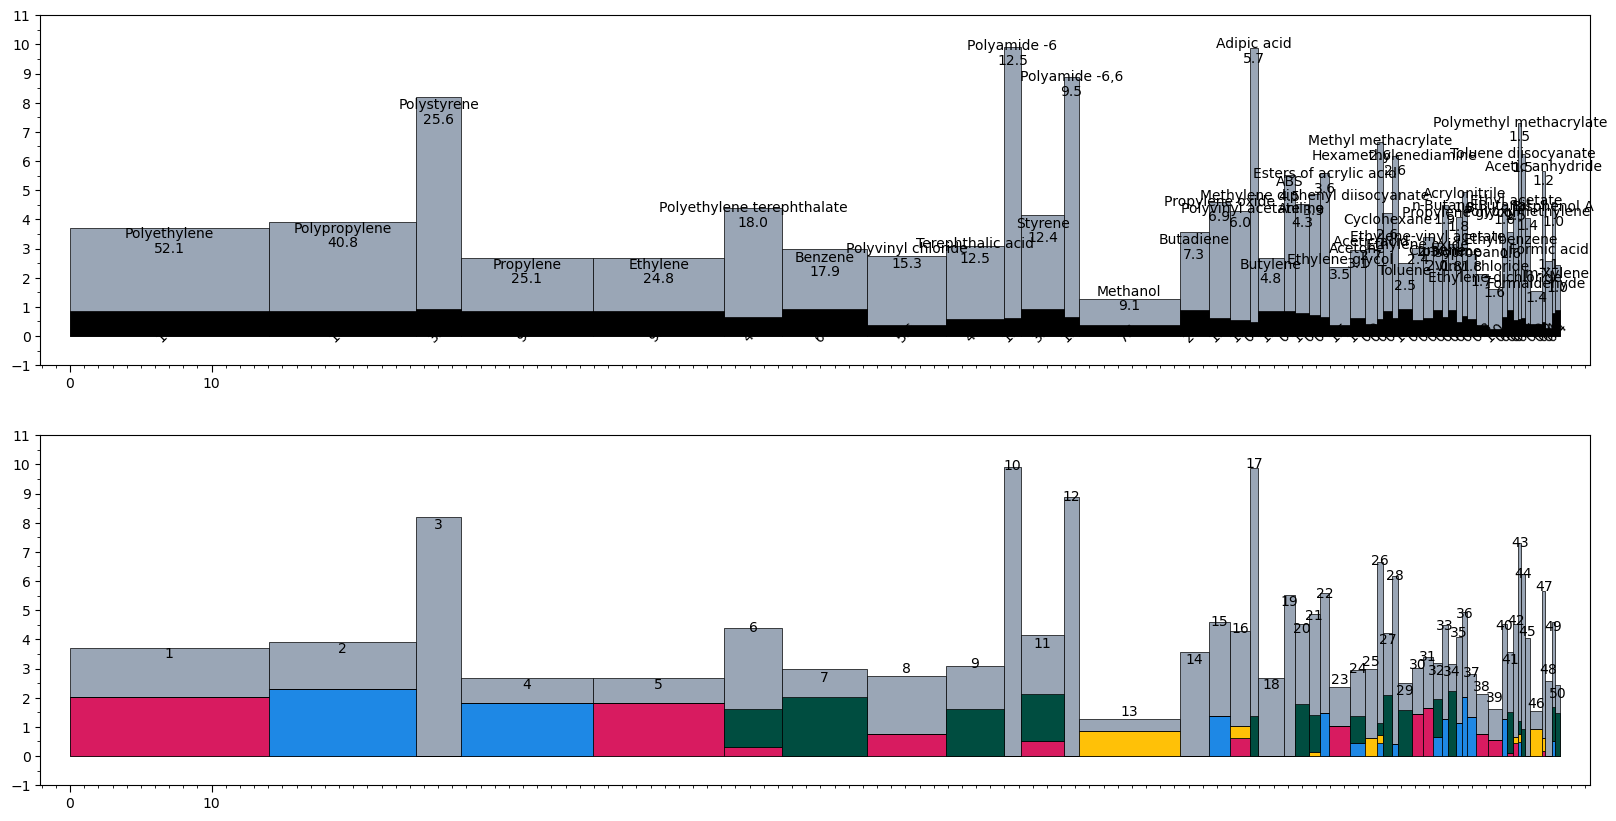

In [44]:
color_palette = ["#9aa6b6", "#d81b60", '#1e88e5','#ffc107','#004d40']

figure = plt.figure(figsize=(20, 10))
plt.rcParams['svg.fonttype'] = 'none'
(ax_1, ax_2) = figure.subplots(2, 1)
#plt.tight_layout()
total_bars = ax_2.bar(x=output_table['x_axis'],
                      height=output_table['GHG total unit impact with end-of-life (IPCC 2021 GWP100, kg CO2e/kg)'], width=output_table['Quantity (Mt)'],
                      align='edge', edgecolor = 'k', linewidth = 0.5, color=color_palette[0])
for bar, (idx, row) in zip(total_bars, output_table.iterrows()):
    gid = f"bar_totalaxes2_{row['Figure name']}_{idx}"  # create any naming scheme you like
    bar.set_gid(gid)
ethylene_bars = ax_2.bar(x=output_table['x_axis'],
                         height=output_table['ethylene'],
                         width=output_table['Quantity (Mt)'], 
                         align='edge', edgecolor = 'k', linewidth = 0.5, color=color_palette[1])
for bar, (idx, row) in zip(ethylene_bars, output_table.iterrows()):
    gid = f"bar_ethylene_{row['Figure name']}_{idx}"  # create any naming scheme you like
    bar.set_gid(gid)
propylene_bars = ax_2.bar(x=output_table['x_axis'],
                          bottom=output_table['ethylene'],
                          height=output_table['propylene'],
                          width=output_table['Quantity (Mt)'],
                          align='edge', edgecolor = 'k', linewidth = 0.5, color=color_palette[2])
for bar, (idx, row) in zip(propylene_bars, output_table.iterrows()):
    gid = f"bar_propylene_{row['Figure name']}_{idx}"  # create any naming scheme you like
    bar.set_gid(gid)
methanol_bars = ax_2.bar(x=output_table['x_axis'],
                         bottom=output_table['ethylene']+output_table['propylene'],
                         height=output_table['methanol'],
                         width=output_table['Quantity (Mt)'],
                         align='edge', edgecolor = 'k', linewidth = 0.5, color=color_palette[3])
for bar, (idx, row) in zip(methanol_bars, output_table.iterrows()):
    gid = f"bar_methanol_{row['Figure name']}_{idx}"  # create any naming scheme you like
    bar.set_gid(gid)

btx_bars = ax_2.bar(x=output_table['x_axis'],
                    bottom=output_table['ethylene']+output_table['propylene']+output_table['methanol'],
                    height=output_table['BTX fraction GHG footprint (IPCC 2021 GWP100, kg CO2e/kg)'],
                    width=output_table['Quantity (Mt)'],
                    align='edge', edgecolor = 'k', linewidth = 0.5, color=color_palette[4])
for bar, (idx, row) in zip(btx_bars, output_table.iterrows()):
    gid = f"bar_btx_{row['Figure name']}_{idx}"  # create any naming scheme you like
    bar.set_gid(gid)


ax_2.set_ylim(bottom=-1, top=11)
ax_2.margins(x=0.02)
#ax.set_xlim(left=0, right=70000)
ax_2.xaxis.set_minor_locator(ticker.MultipleLocator(1))
ax_2.xaxis.set_major_locator(ticker.FixedLocator([0, 10]))

ax_2.yaxis.set_major_locator(ticker.MultipleLocator(1))
ax_2.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))

ax_2.tick_params(axis='x', which='major', length=5)
#ax_2.set_ymargin(1)


ax_1.set_ylim(bottom=-1, top=11)
ax_1.margins(x=0.02)
#ax.set_xlim(left=0, right=70000)
ax_1.xaxis.set_minor_locator(ticker.MultipleLocator(1))
ax_1.xaxis.set_major_locator(ticker.FixedLocator([0, 10]))

ax_1.yaxis.set_major_locator(ticker.MultipleLocator(1))
ax_1.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))

ax_1.tick_params(axis='x', which='major', length=5)


total_bars_ax_1 = ax_1.bar(x=output_table['x_axis'], height=output_table['GHG total unit impact with end-of-life (IPCC 2021 GWP100, kg CO2e/kg)'],
                           width=output_table['Quantity (Mt)'], align='edge', edgecolor = 'k', linewidth = 0.5,
                           color=color_palette[0])
for bar, (idx, row) in zip(total_bars_ax_1, output_table.iterrows()):
    gid = f"bar_totalaxes1_{row['PRODCOM code']}_{idx}"  # create any naming scheme you like
    bar.set_gid(gid)

eol_bars = ax_1.bar(x=output_table['x_axis'],
                    # bottom=output_table['ethylene']+output_table['propylene']+output_table['methanol']+output_table['BTX fraction GHG footprint (IPCC 2021 GWP100, kg CO2e/kg)'],
                    height=output_table['GHG unit impact of end-of-life (IPCC 2021 GWP100, kg CO2e/kg)'],
                    width=output_table['Quantity (Mt)'],
                    align='edge', edgecolor = 'k', linewidth = 0.5, color='black')
for bar, (idx, row) in zip(eol_bars, output_table.iterrows()):
    gid = f"bar_eol_{row['Figure name']}_{idx}"  # create any naming scheme you like
    bar.set_gid(gid)


add_labels_total_impact(ax=ax_1, x=output_table['x_axis'], quantity=output_table['Quantity (Mt)'], y=output_table['GHG unit impact (IPCC 2021 GWP100, kg CO2e/kg)'],
                        amount=output_table['Total GHG footprint with end-of-life (IPCC 2021 GWP100, kg CO2e/kg)'], id=output_table['Figure name'])
add_labels_quantities(ax=ax_1, x=output_table['x_axis'], quantity=output_table['Quantity (Mt)'],
                      amount=output_table['Quantity (Mt)'], id=output_table['Figure name'])
#add_labels_unit_impact(ax=ax_2, x=output_table['x_axis'], quantity=output_table['Quantity'], y=output_table['unit impact'], amount=output_table['unit impact'], id=output_table['PRCCODE (Labels)'])

add_labels_code(ax=ax_2, x=output_table['x_axis'], quantity=output_table['Quantity (Mt)'], y=output_table['GHG unit impact (IPCC 2021 GWP100, kg CO2e/kg)'],
              value=output_table['Priority code'], id=output_table['Figure name'])

add_labels_name(ax=ax_1, x=output_table['x_axis'], quantity=output_table['Quantity (Mt)'], y=output_table['GHG unit impact (IPCC 2021 GWP100, kg CO2e/kg)'],
              name=output_table['Figure name'], id=output_table['Figure name'])

# NOTE: Save figure to file
plt.savefig("output/figure.svg")

## Figure post-treatment

In [45]:
import xml.etree.ElementTree as ET

In [46]:
# Source : 27-10-2025 - https://chatgpt.com/c/68ff4810-10a4-832e-b90a-33369191ba4c
# 3) Parse SVG and create a group wrapping the bars
# Note: the SVG has a default namespace; we handle it explicitly.
SVG_NS = "http://www.w3.org/2000/svg"
NS = {"svg": SVG_NS}
ET.register_namespace("", SVG_NS)  # preserve default namespace on write

tree = ET.parse('output/figure.svg')

In [47]:
import re

def postProcessSVG(root, axes_list=['axes_1', 'axes_2']):
    for axes in axes_list:
        axes_element = root.find(f".//svg:g[@id='{axes}']", NS)

        element_list = [e.get('id') for e in axes_element.findall(".//svg:g[@id]", NS)]
        patterns = []
        r = re.compile("^(.*?_.*?)_.*")

        for el in element_list:
            match = r.match(el)
            if match and match.group(1):
                pattern_group = match.group(1)
                patterns.append(pattern_group)

        patterns = list(reversed(list(set(patterns))))

        for pattern in patterns:
        
            # Find all elements that are bar paths/rects by id pattern "bar_..."
            # They might be <path> or <rect> depending on style/backend
            bar_elems = []
            for elem in axes_element.findall(".//svg:g", NS):
                eid = elem.get("id")
                if eid and eid.startswith(pattern):
                    bar_elems.append(elem)
            
            if not bar_elems:
                raise RuntimeError("No elements found with id starting 'bar_'. \
                                   Check the GIDs on bars and the SVG content.")
            else:
                bar_elems

            # Find where to insert the group: common place is as a child of the main <g> that contains axes.
            # We'll insert the new group as a child of the root SVG for simplicity.
            svg_group_element = ET.Element(f"{{{SVG_NS}}}g", {"id": f"group_{pattern}"})

            # Move each bar element into the new group.
            # Removing from the original parent requires finding that parent.
            def find_parent(root_node, child):
                for p in root_node.iter():
                    for c in p:
                        if c is child:
                            return p
                return None

            for e in bar_elems:
                parent = axes_element.find(f".//svg:g[@id='{e.get('id')}']/..", NS)
                # parent = find_parent(root, e)
                if parent is None:
                    continue
                parent.remove(e)
                svg_group_element.append(e)

            # Insert group into root (or into a suitable parent if you prefer)
            axes_element.append(svg_group_element)

In [48]:
# Source : 27-10-2025 - https://chatgpt.com/c/68ff4810-10a4-832e-b90a-33369191ba4c
def flatten(node):
    """Remove <g> elements that only contain a single child and no attributes."""
    for child in list(node):
        flatten(child)
    # If a <g> has only one child and no attributes other than id, flatten it
    for g in list(node.findall(f"{{{SVG_NS}}}g")):
        children = list(g)
        attrs = {k: v for k, v in g.attrib.items() if k != "id"}
        if len(children) == 1 and not attrs:
            child = children[0]
            if "id" in g.attrib and "id" not in child.attrib:
                child.attrib["id"] = g.attrib["id"]
            node.insert(list(node).index(g), child)
            node.remove(g)

In [49]:
root = tree.getroot()
postProcessSVG(root)
flatten(root)

In [50]:
# 4) Write out modified SVG
export_tree = ET.ElementTree(root)
export_tree.write("output/grouped_bars.svg", encoding="utf-8", xml_declaration=True)

print("Saved grouped_bars.svg with <g id='group_series1'> containing bar_* elements.")

Saved grouped_bars.svg with <g id='group_series1'> containing bar_* elements.
